In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df_original = pd.read_csv("Traffic_Violations.csv", low_memory=False)

print("Dataset loaded successfully.")
print("Shape:", df_original.shape)

Dataset loaded successfully.
Shape: (1292399, 35)


In [4]:
print(df_original["Violation Type"].value_counts())
print("\nUnique values:")
print(df_original["Violation Type"].unique())

Violation Type
Warning     620103
Citation    607150
ESERO        64224
SERO           922
Name: count, dtype: int64

Unique values:
<StringArray>
['Citation', 'Warning', 'ESERO', 'SERO']
Length: 4, dtype: str


In [3]:
df = df_original.copy()

df["Violation Type"] = df["Violation Type"].replace({
    "ESERO": "Repair Order",
    "SERO": "Repair Order"})

print("Final target distribution:")
print(df["Violation Type"].value_counts())

print("\nClasses:")
print(df["Violation Type"].unique())

Final target distribution:
Violation Type
Warning         620103
Citation        607150
Repair Order     65146
Name: count, dtype: int64

Classes:
<StringArray>
['Citation', 'Warning', 'Repair Order']
Length: 3, dtype: str


In [4]:
SAMPLE_SIZE = 500000

df = df.sample(
    n=SAMPLE_SIZE,
    random_state=42).copy()

print("Working dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["Violation Type"].value_counts())

Working dataset shape: (500000, 35)

Target distribution:
Violation Type
Warning         239638
Citation        235195
Repair Order     25167
Name: count, dtype: int64


In [5]:
X = df.drop(columns=["Violation Type"]).copy()
y = df["Violation Type"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500000, 34)
y shape: (500000,)


In [6]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y.astype(str))

print("Target mapping:")

for i, label in enumerate(target_encoder.classes_):
    print(f"{i} -> {label}")

Target mapping:
0 -> Citation
1 -> Repair Order
2 -> Warning


In [9]:
# Convert Date Of Stop into useful numeric features
if "Date Of Stop" in X.columns:
    date_series = pd.to_datetime(
        X["Date Of Stop"],
        errors="coerce")

    X["Stop_Year"] = date_series.dt.year
    X["Stop_Month"] = date_series.dt.month
    X["Stop_Day"] = date_series.dt.day
    X["Stop_DayOfWeek"] = date_series.dt.dayofweek

    X.drop(columns=["Date Of Stop"], inplace=True)

# Convert Time Of Stop into hour/minute
if "Time Of Stop" in X.columns:
    time_series = pd.to_datetime(
        X["Time Of Stop"],
        errors="coerce")

    X["Stop_Hour"] = time_series.dt.hour
    X["Stop_Minute"] = time_series.dt.minute

    X.drop(columns=["Time Of Stop"], inplace=True)

print("Feature engineering completed.")
print("Current X shape:", X.shape)
print("\nCurrent columns:")
print(X.columns.tolist())

C:\Users\Shresta\AppData\Local\Temp\ipykernel_17416\600387998.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_series = pd.to_datetime(


Feature engineering completed.
Current X shape: (500000, 38)

Current columns:
['Agency', 'SubAgency', 'Description', 'Location', 'Latitude', 'Longitude', 'Accident', 'Belts', 'Personal Injury', 'Property Damage', 'Fatal', 'Commercial License', 'HAZMAT', 'Commercial Vehicle', 'Alcohol', 'Work Zone', 'State', 'VehicleType', 'Year', 'Make', 'Model', 'Color', 'Charge', 'Article', 'Contributed To Accident', 'Race', 'Gender', 'Driver City', 'Driver State', 'DL State', 'Arrest Type', 'Geolocation', 'Stop_Year', 'Stop_Month', 'Stop_Day', 'Stop_DayOfWeek', 'Stop_Hour', 'Stop_Minute']


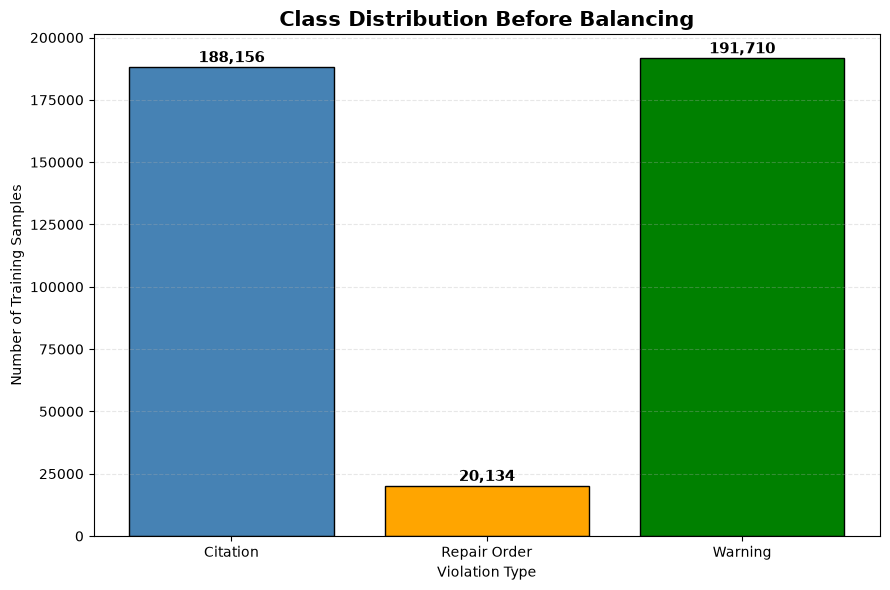

In [ ]:
# Class Distribution Before Balancing

class_counts_before = pd.Series(y_train).value_counts().sort_index()
class_names = target_encoder.classes_

colors = ["steelblue", "orange", "green"]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    class_names,
    class_counts_before.values,
    color=colors,
    edgecolor="black")

plt.title(
    "Class Distribution Before Balancing",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Violation Type")
plt.ylabel("Number of Training Samples")

for bar, count in zip(bars, class_counts_before.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f"{count:,}",
        ha="center",
        fontsize=11,
        fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "class_distribution_before_balancing.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

In [ ]:

# Start again from the original working dataframe
X = df.drop(columns=["Violation Type"]).copy()

# --- Date features ---
if "Date Of Stop" in X.columns:
    date_series = pd.to_datetime(
        X["Date Of Stop"].astype(str),
        errors="coerce"
    )

    X["Stop_Year"] = date_series.dt.year
    X["Stop_Month"] = date_series.dt.month
    X["Stop_Day"] = date_series.dt.day
    X["Stop_DayOfWeek"] = date_series.dt.dayofweek

    X.drop(columns=["Date Of Stop"], inplace=True)

# --- Time features ---
if "Time Of Stop" in X.columns:
    time_series = pd.to_datetime(
        X["Time Of Stop"].astype(str),
        errors="coerce"
    )

    X["Stop_Hour"] = time_series.dt.hour
    X["Stop_Minute"] = time_series.dt.minute

    X.drop(columns=["Time Of Stop"], inplace=True)

# --- Remove high-cardinality text fields ---
columns_to_drop = [
    "Description",
    "Location",
    "Geolocation",
    "Charge"
]

X.drop(
    columns=[c for c in columns_to_drop if c in X.columns],
    inplace=True
)

print("X rebuilt successfully.")
print("Shape:", X.shape)
print("\nDtypes:")
print(X.dtypes)

C:\Users\Shresta\AppData\Local\Temp\ipykernel_20080\774217318.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_series = pd.to_datetime(


X rebuilt successfully.
Shape: (500000, 34)

Dtypes:
Agency                         str
SubAgency                      str
Latitude                   float64
Longitude                  float64
Accident                       str
Belts                          str
Personal Injury                str
Property Damage                str
Fatal                          str
Commercial License             str
HAZMAT                         str
Commercial Vehicle             str
Alcohol                        str
Work Zone                      str
State                          str
VehicleType                    str
Year                       float64
Make                           str
Model                          str
Color                          str
Article                        str
Contributed To Accident        str
Race                           str
Gender                         str
Driver City                    str
Driver State                   str
DL State                       str
Ar

In [8]:
from pandas.api.types import is_numeric_dtype

# Rebuild X from the original clean working dataframe
X = df.drop(columns=["Violation Type"]).copy()

# -----------------------------
# Date features
# -----------------------------
if "Date Of Stop" in X.columns:
    date_series = pd.to_datetime(
        X["Date Of Stop"],
        errors="coerce"
    )

    X["Stop_Year"] = date_series.dt.year
    X["Stop_Month"] = date_series.dt.month
    X["Stop_Day"] = date_series.dt.day
    X["Stop_DayOfWeek"] = date_series.dt.dayofweek

    X.drop(columns=["Date Of Stop"], inplace=True)

# -----------------------------
# Time features
# -----------------------------
if "Time Of Stop" in X.columns:
    time_series = pd.to_datetime(
        X["Time Of Stop"],
        errors="coerce"
    )

    X["Stop_Hour"] = time_series.dt.hour
    X["Stop_Minute"] = time_series.dt.minute

    X.drop(columns=["Time Of Stop"], inplace=True)

# -----------------------------
# Remove high-cardinality text fields
# -----------------------------
columns_to_drop = [
    "Description",
    "Location",
    "Geolocation",
    "Charge"
]

X.drop(
    columns=[c for c in columns_to_drop if c in X.columns],
    inplace=True
)

# -----------------------------
# Encode categorical features
# -----------------------------
feature_encoders = {}

for col in X.columns:

    # Anything that is NOT numeric is treated as categorical
    if not is_numeric_dtype(X[col]):

        X[col] = X[col].astype("string").fillna("Unknown")

        encoder = LabelEncoder()
        X[col] = encoder.fit_transform(X[col])

        feature_encoders[col] = encoder

    else:

        X[col] = pd.to_numeric(
            X[col],
            errors="coerce"
        )

        X[col] = X[col].fillna(
            X[col].median()
        )

print("Encoding completed.")
print("Total missing values:", X.isnull().sum().sum())
print("Final X shape:", X.shape)

C:\Users\Shresta\AppData\Local\Temp\ipykernel_20080\1392554188.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_series = pd.to_datetime(


Encoding completed.
Total missing values: 0
Final X shape: (500000, 34)


In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(
    pd.Series(y_train)
    .value_counts(normalize=True)
    .sort_index())

print("\nTesting class distribution:")
print(
    pd.Series(y_test)
    .value_counts(normalize=True)
    .sort_index())

Training samples: 400000
Testing samples: 100000

Training class distribution:
0    0.470390
1    0.050335
2    0.479275
Name: proportion, dtype: float64

Testing class distribution:
0    0.47039
1    0.05033
2    0.47928
Name: proportion, dtype: float64


In [10]:
# Decision Tree

dt_model = DecisionTreeClassifier(
    random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Test Accuracy: {dt_accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Test Accuracy: 71.54%

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.73      0.71     47039
           1       1.00      1.00      1.00      5033
           2       0.72      0.67      0.69     47928

    accuracy                           0.72    100000
   macro avg       0.80      0.80      0.80    100000
weighted avg       0.72      0.72      0.72    100000



In [11]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Test Accuracy: {rf_accuracy:.2%}")
print(classification_report(y_test, rf_pred))

Random Forest Test Accuracy: 77.51%
              precision    recall  f1-score   support

           0       0.80      0.70      0.74     47039
           1       1.00      1.00      1.00      5033
           2       0.74      0.83      0.78     47928

    accuracy                           0.78    100000
   macro avg       0.84      0.84      0.84    100000
weighted avg       0.78      0.78      0.77    100000



In [12]:
# XGBoost

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=2,
    gamma=0,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print(f"XGBoost Test Accuracy: {xgb_accuracy:.2%}")
print(classification_report(y_test, xgb_pred))

XGBoost Test Accuracy: 70.75%
              precision    recall  f1-score   support

           0       0.72      0.61      0.66     47039
           1       1.00      1.00      1.00      5033
           2       0.67      0.77      0.72     47928

    accuracy                           0.71    100000
   macro avg       0.80      0.79      0.79    100000
weighted avg       0.71      0.71      0.71    100000



In [13]:
# Voting Classifier

from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ("dt", dt_model),
        ("rf", rf_model),
        ("xgb", xgb_model)],
    voting="soft")

voting_model.fit(X_train, y_train)

voting_pred = voting_model.predict(X_test)

voting_accuracy = accuracy_score(y_test, voting_pred)

print(f"Voting Test Accuracy: {voting_accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, voting_pred))

Voting Test Accuracy: 72.85%

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.73      0.72     47039
           1       1.00      1.00      1.00      5033
           2       0.72      0.70      0.71     47928

    accuracy                           0.73    100000
   macro avg       0.81      0.81      0.81    100000
weighted avg       0.73      0.73      0.73    100000



In [14]:
# STACKING classifier


stacking_model = StackingClassifier(
    estimators=[
        ("dt", dt_model),
        ("rf", rf_model),
        ("xgb", xgb_model)],
    final_estimator=LogisticRegression(
        max_iter=2000),
    cv=5,
    n_jobs=-1)

stacking_model.fit(X_train, y_train)

stacking_pred = stacking_model.predict(X_test)

stacking_accuracy = accuracy_score(
    y_test,
    stacking_pred)

print(f"Stacking Test Accuracy: {stacking_accuracy:.2%}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        stacking_pred,
        target_names=target_encoder.classes_))

Stacking Test Accuracy: 77.56%

Classification Report:
              precision    recall  f1-score   support

    Citation       0.79      0.71      0.75     47039
Repair Order       1.00      1.00      1.00      5033
     Warning       0.74      0.82      0.78     47928

    accuracy                           0.78    100000
   macro avg       0.84      0.84      0.84    100000
weighted avg       0.78      0.78      0.77    100000



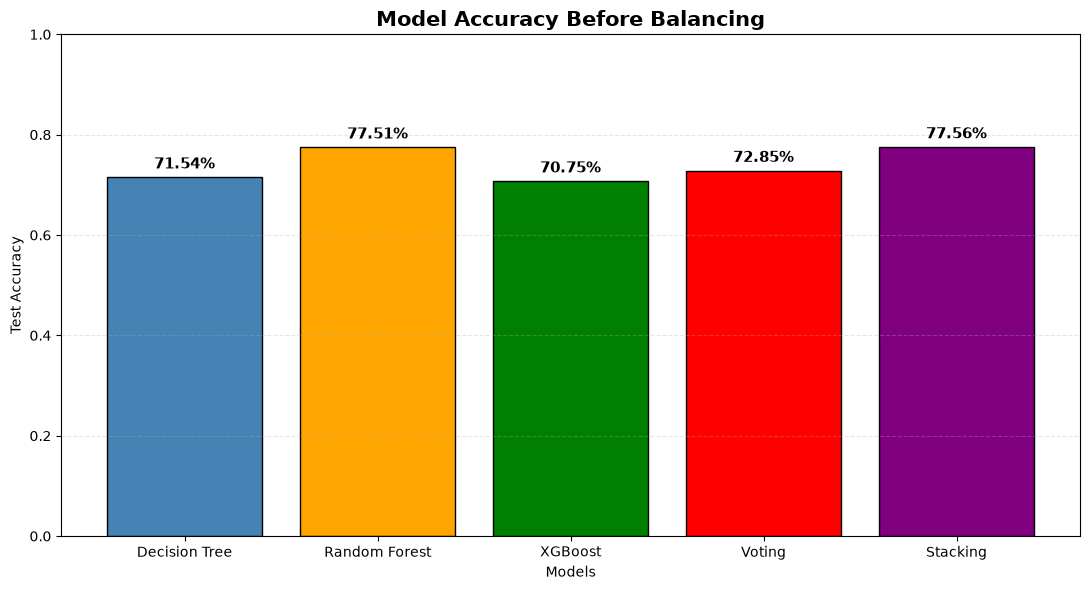

In [17]:
# Model Accuracy Before Balancing


models = [
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Voting",
    "Stacking"]

accuracies_before = [
    dt_accuracy,
    rf_accuracy,
    xgb_accuracy,
    voting_accuracy,
    stacking_accuracy]

colors = [
    "steelblue",
    "orange",
    "green",
    "red",
    "purple"]

plt.figure(figsize=(11, 6))

bars = plt.bar(
    models,
    accuracies_before,
    color=colors,
    edgecolor="black")

plt.title(
    "Model Accuracy Before Balancing",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Models")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

for bar, acc in zip(bars, accuracies_before):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.2%}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "model_accuracy_before_balancing.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

In [18]:
# Balance Training Data


from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train,
    y_train)

print("Before balancing:")
print(
    pd.Series(y_train)
    .value_counts()
    .sort_index())

print("\nAfter Random Oversampling:")
print(
    pd.Series(y_train_balanced)
    .value_counts()
    .sort_index())

Before balancing:
0    188156
1     20134
2    191710
Name: count, dtype: int64

After Random Oversampling:
0    191710
1    191710
2    191710
Name: count, dtype: int64


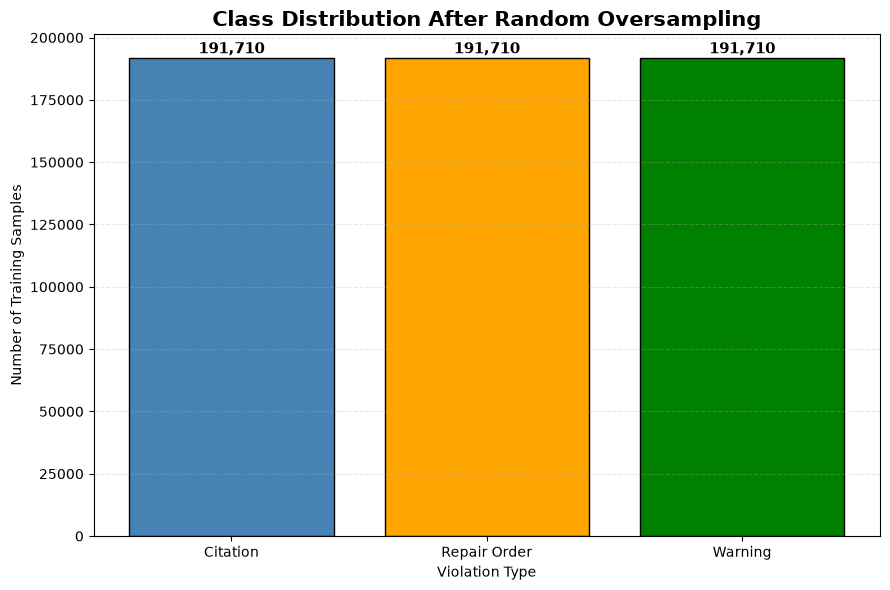

In [19]:
# Class Distribution After Balancing

class_counts_after = (
    pd.Series(y_train_balanced)
    .value_counts()
    .sort_index())

class_names = target_encoder.classes_

colors = [
    "steelblue",  # Citation
    "orange",     # Repair Order
    "green"       # Warning
    ]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    class_names,
    class_counts_after.values,
    color=colors,
    edgecolor="black")

plt.title(
    "Class Distribution After Random Oversampling",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Violation Type")
plt.ylabel("Number of Training Samples")

for bar, count in zip(bars, class_counts_after.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f"{count:,}",
        ha="center",
        fontsize=11,
        fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "class_distribution_after_balancing.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

In [22]:
# Decision Tree after Balancing


dt_model_balanced = DecisionTreeClassifier(
    random_state=42)

dt_model_balanced.fit(
    X_train_balanced,
    y_train_balanced)

dt_pred_balanced = dt_model_balanced.predict(X_test)

dt_accuracy_balanced = accuracy_score(
    y_test,
    dt_pred_balanced)

print(
    f"Decision Tree After Balancing: "
    f"({dt_accuracy_balanced:.2%})")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        dt_pred_balanced,
        target_names=target_encoder.classes_))

Decision Tree After Balancing: (71.27%)

Classification Report:
              precision    recall  f1-score   support

    Citation       0.68      0.73      0.71     47039
Repair Order       1.00      1.00      1.00      5033
     Warning       0.72      0.66      0.69     47928

    accuracy                           0.71    100000
   macro avg       0.80      0.80      0.80    100000
weighted avg       0.71      0.71      0.71    100000



In [21]:
# Random Forest After Random Oversampling


rf_model_balanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1)

rf_model_balanced.fit(
    X_train_balanced,
    y_train_balanced)

rf_pred_balanced = rf_model_balanced.predict(X_test)

rf_accuracy_balanced = accuracy_score(
    y_test,
    rf_pred_balanced)

print(
    f"Random Forest After Balancing: "
    f"{rf_accuracy_balanced:.4f} ({rf_accuracy_balanced:.2%})")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred_balanced,
        target_names=target_encoder.classes_))

Random Forest After Balancing: 0.7745 (77.45%)

Classification Report:
              precision    recall  f1-score   support

    Citation       0.80      0.70      0.74     47039
Repair Order       1.00      1.00      1.00      5033
     Warning       0.74      0.83      0.78     47928

    accuracy                           0.77    100000
   macro avg       0.84      0.84      0.84    100000
weighted avg       0.78      0.77      0.77    100000



In [23]:
# XGBoost After Random Oversampling

xgb_model_balanced = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=2,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1)

xgb_model_balanced.fit(
    X_train_balanced,
    y_train_balanced)

xgb_pred_balanced = xgb_model_balanced.predict(X_test)

xgb_accuracy_balanced = accuracy_score(
    y_test,
    xgb_pred_balanced)

print(
    f"XGBoost After Balancing: "
    f"({xgb_accuracy_balanced:.2%})")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred_balanced,
        target_names=target_encoder.classes_))

XGBoost After Balancing: (70.70%)

Classification Report:
              precision    recall  f1-score   support

    Citation       0.72      0.62      0.67     47039
Repair Order       1.00      1.00      1.00      5033
     Warning       0.67      0.76      0.71     47928

    accuracy                           0.71    100000
   macro avg       0.80      0.79      0.79    100000
weighted avg       0.71      0.71      0.71    100000



In [24]:
# Voting After Random Oversampling


voting_model_balanced = VotingClassifier(
    estimators=[
        ("dt", dt_model_balanced),
        ("rf", rf_model_balanced),
        ("xgb", xgb_model_balanced)],
    voting="soft")

voting_model_balanced.fit(
    X_train_balanced,
    y_train_balanced)

voting_pred_balanced = voting_model_balanced.predict(X_test)

voting_accuracy_balanced = accuracy_score(
    y_test,
    voting_pred_balanced)

print(
    f"Voting After Balancing: "
    f"({voting_accuracy_balanced:.2%})")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        voting_pred_balanced,
        target_names=target_encoder.classes_))

Voting After Balancing: (72.58%)

Classification Report:
              precision    recall  f1-score   support

    Citation       0.70      0.73      0.71     47039
Repair Order       1.00      1.00      1.00      5033
     Warning       0.72      0.70      0.71     47928

    accuracy                           0.73    100000
   macro avg       0.81      0.81      0.81    100000
weighted avg       0.73      0.73      0.73    100000



In [25]:
# Stacking After Random Oversampling

stacking_model_balanced = StackingClassifier(
    estimators=[
        ("dt", dt_model_balanced),
        ("rf", rf_model_balanced),
        ("xgb", xgb_model_balanced)],
    final_estimator=LogisticRegression(
        max_iter=2000),
    cv=5,
    n_jobs=-1)

stacking_model_balanced.fit(
    X_train_balanced,
    y_train_balanced)

stacking_pred_balanced = stacking_model_balanced.predict(X_test)

stacking_accuracy_balanced = accuracy_score(
    y_test,
    stacking_pred_balanced)

print(
    f"Stacking After Balancing: "
    f"({stacking_accuracy_balanced:.2%})")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        stacking_pred_balanced,
        target_names=target_encoder.classes_))

Stacking After Balancing: (77.51%)

Classification Report:
              precision    recall  f1-score   support

    Citation       0.79      0.71      0.75     47039
Repair Order       1.00      1.00      1.00      5033
     Warning       0.74      0.82      0.78     47928

    accuracy                           0.78    100000
   macro avg       0.84      0.84      0.84    100000
weighted avg       0.78      0.78      0.77    100000



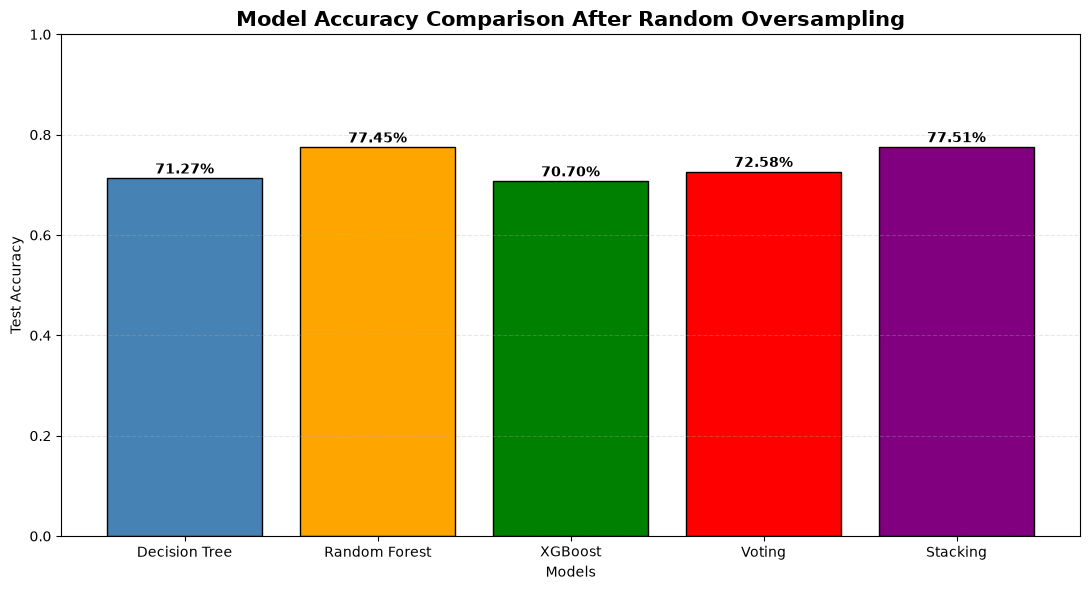

In [28]:
# Model Accuracy Comparison AFTER Balancing


models = [
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Voting",
    "Stacking"]

accuracy_after = [
    dt_accuracy_balanced,
    rf_accuracy_balanced,
    xgb_accuracy_balanced,
    voting_accuracy_balanced,
    stacking_accuracy_balanced]

colors = [
    "steelblue",
    "orange",
    "green",
    "red",
    "purple"]

plt.figure(figsize=(11, 6))

bars = plt.bar(
    models,
    accuracy_after,
    color=colors,
    edgecolor="black")

plt.title(
    "Model Accuracy Comparison After Random Oversampling",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Models")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

for bar, accuracy in zip(bars, accuracy_after):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{accuracy * 100:.2f}%",
        ha="center",
        fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "01_model_accuracy_after_balancing.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

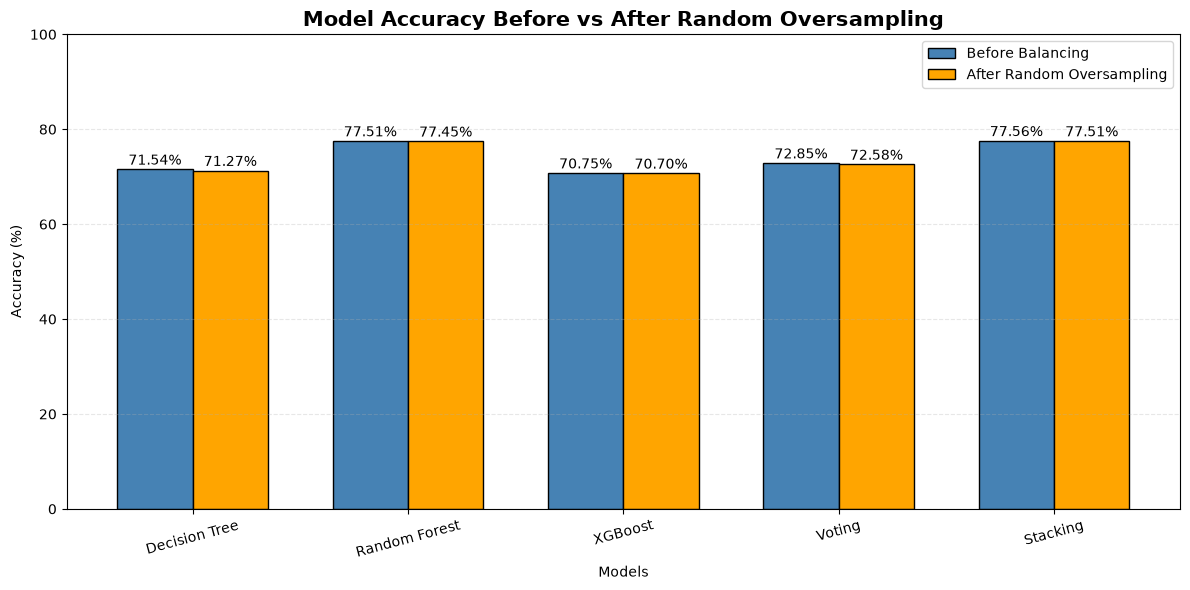

In [29]:
# Model Accuracy Before vs After Balancing

accuracy_before = [
    dt_accuracy,
    rf_accuracy,
    xgb_accuracy,
    voting_accuracy,
    stacking_accuracy]

accuracy_after = [
    dt_accuracy_balanced,
    rf_accuracy_balanced,
    xgb_accuracy_balanced,
    voting_accuracy_balanced,
    stacking_accuracy_balanced]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    np.array(accuracy_before) * 100,
    width,
    label="Before Balancing",
    color="steelblue",
    edgecolor="black")

bars2 = plt.bar(
    x + width / 2,
    np.array(accuracy_after) * 100,
    width,
    label="After Random Oversampling",
    color="orange",
    edgecolor="black")

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.title(
    "Model Accuracy Before vs After Random Oversampling",
    fontsize=15,
    fontweight="bold")

plt.xticks(x, models, rotation=15)
plt.ylim(0, 100)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.2f}%",
            ha="center",
            fontsize=10)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "02_accuracy_before_vs_after_balancing.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

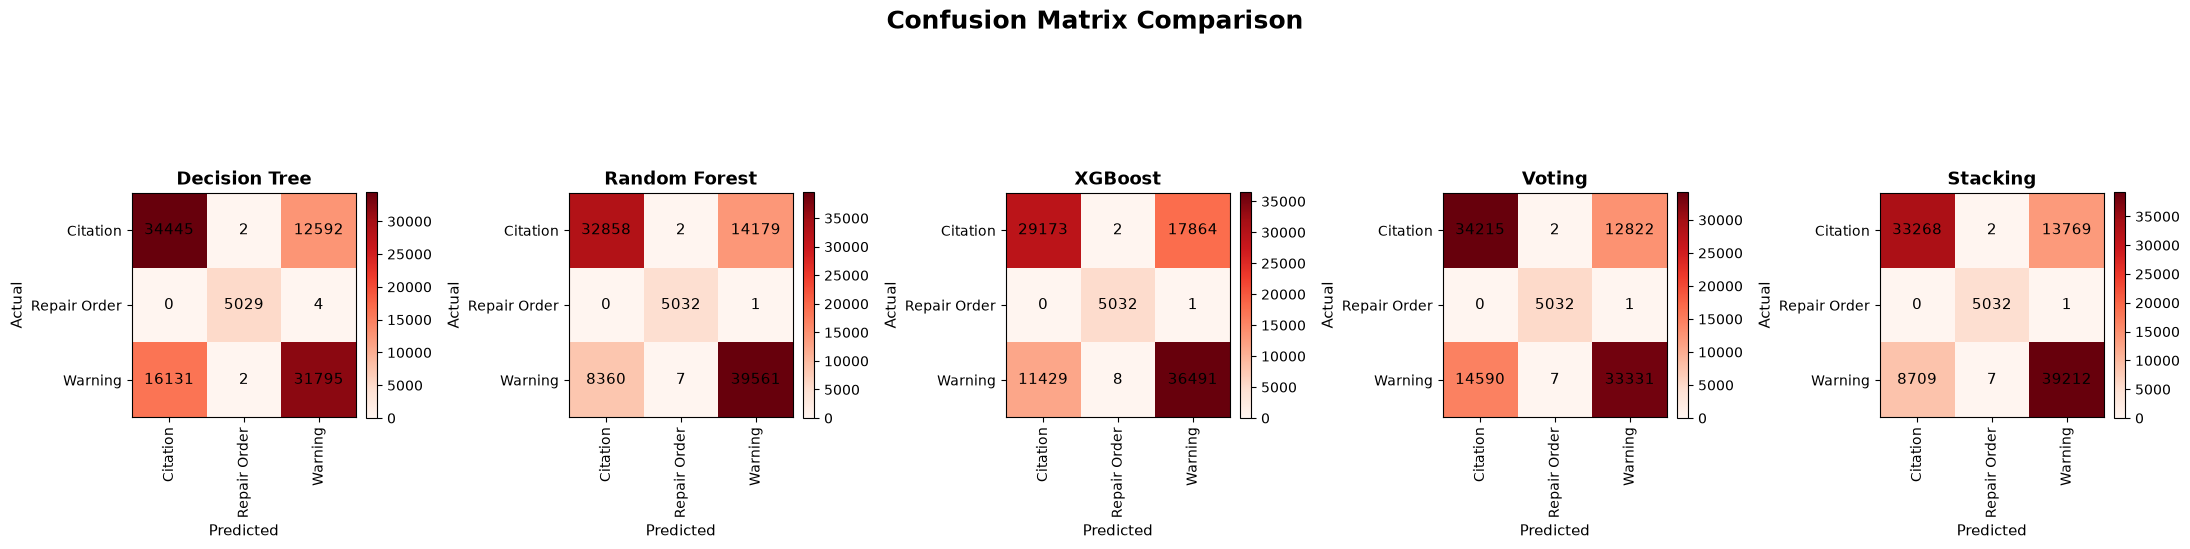

In [ ]:
# Confusion Matrix Comparison - Final Balanced Models


import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

balanced_predictions = {
    "Decision Tree": dt_pred_balanced,
    "Random Forest": rf_pred_balanced,
    "XGBoost": xgb_pred_balanced,
    "Voting": voting_pred_balanced,
    "Stacking": stacking_pred_balanced}

class_labels = target_encoder.classes_

fig, axes = plt.subplots(
    1, 5,
    figsize=(22, 6))

for ax, (model_name, prediction) in zip(
    axes,
    balanced_predictions.items()):

    cm = confusion_matrix(
        y_test,
        prediction)

    # Draw heatmap manually
    image = ax.imshow(
        cm,
        cmap="Reds")

    # Add values inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                f"{cm[i, j]}",
                ha="center",
                va="center",
                fontsize=11)

    ax.set_title(
        model_name,
        fontsize=13,
        fontweight="bold")

    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)

    ax.set_xticks(range(3))
    ax.set_yticks(range(3))

    ax.set_xticklabels(
        class_labels,
        rotation=90)

    ax.set_yticklabels(
        class_labels)

    # Color bar for each matrix
    fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04)

fig.suptitle(
    "Confusion Matrix Comparison",
    fontsize=18,
    fontweight="bold")

plt.tight_layout()

plt.savefig(
    "Final_Confusion_Matrix_Comparison.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

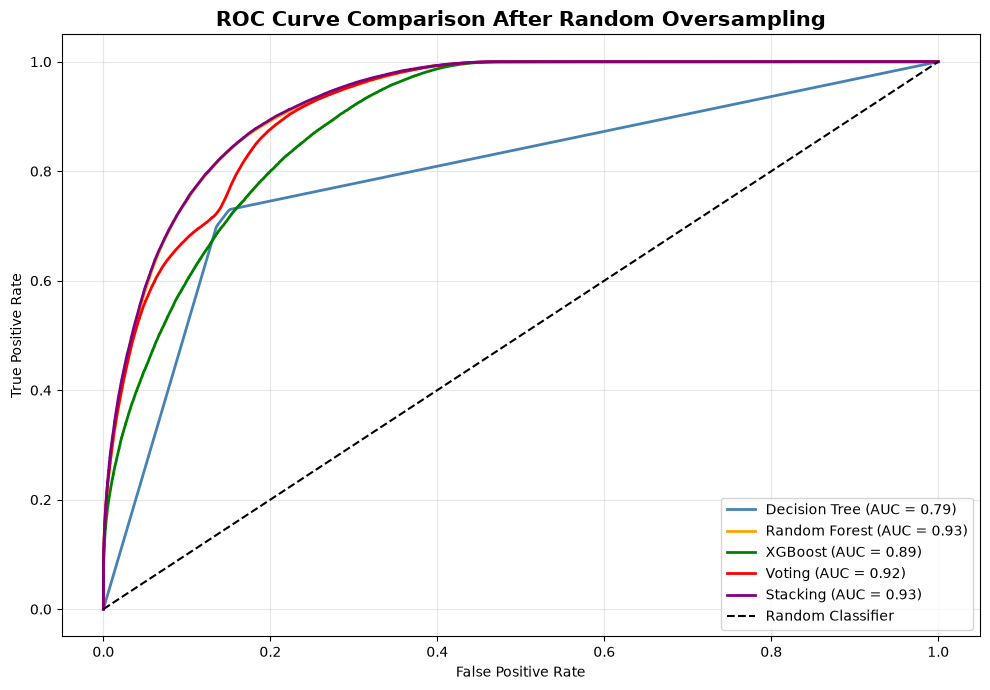

In [33]:
# ROC Curve Comparison

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(
    y_test,
    classes=[0, 1, 2])

model_objects = {
    "Decision Tree": dt_model_balanced,
    "Random Forest": rf_model_balanced,
    "XGBoost": xgb_model_balanced,
    "Voting": voting_model_balanced,
    "Stacking": stacking_model_balanced}

colors = [
    "steelblue",
    "orange",
    "green",
    "red",
    "purple"]

plt.figure(figsize=(10, 7))

for (model_name, model), color in zip(
    model_objects.items(),
    colors):

    probabilities = model.predict_proba(X_test)

    # Plot class-wise micro-average ROC
    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        probabilities.ravel())

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Classifier")

plt.title(
    "ROC Curve Comparison After Random Oversampling",
    fontsize=15,
    fontweight="bold")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(
    loc="lower right")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "04_roc_curve_comparison_balanced.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

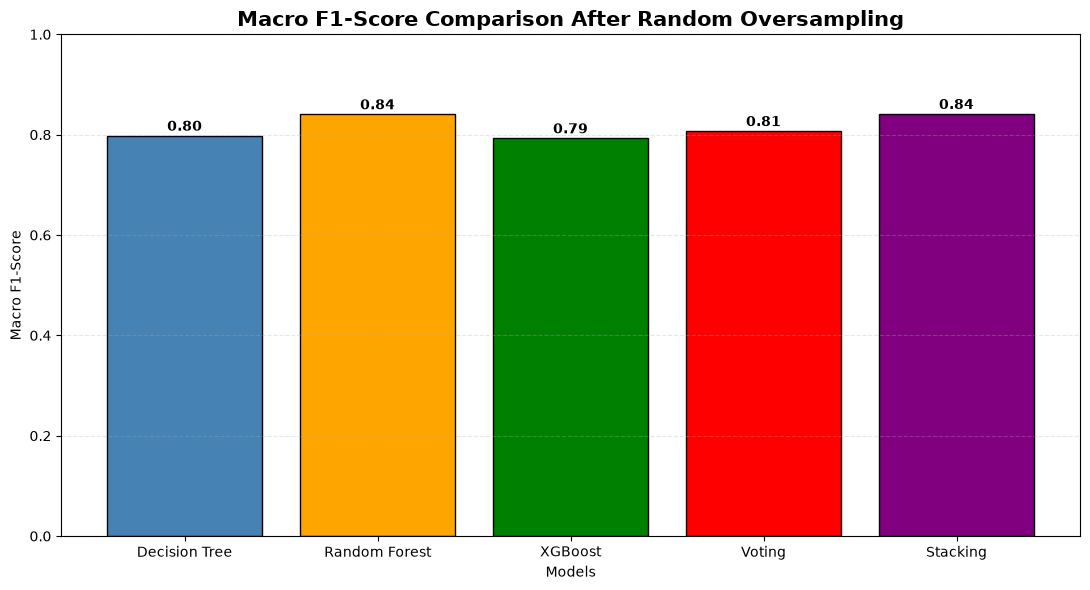

In [34]:
# Macro F1 Comparison After Balancing


from sklearn.metrics import f1_score

macro_f1_after = []

for model_name in models:

    score = f1_score(
        y_test,
        balanced_predictions[model_name],
        average="macro")

    macro_f1_after.append(score)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    models,
    macro_f1_after,
    color=colors,
    edgecolor="black")

plt.title(
    "Macro F1-Score Comparison After Random Oversampling",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Models")
plt.ylabel("Macro F1-Score")
plt.ylim(0, 1)

for bar, score in zip(
    bars,
    macro_f1_after):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{score:.2f}",
        ha="center",
        fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "05_macro_f1_after_balancing.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

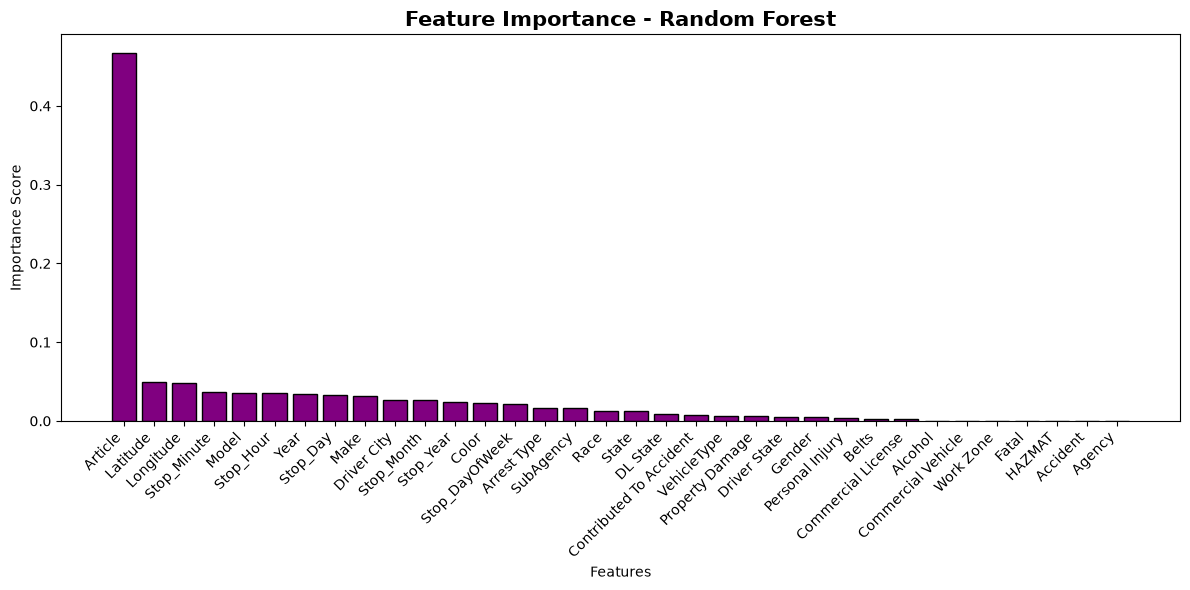

In [ ]:

# Feature Importance - Random Forest


feature_names = X.columns.tolist()

importances = rf_model_balanced.feature_importances_

indices = np.argsort(importances)[::-1]

sorted_features = [
    feature_names[i]
    for i in indices]

sorted_importances = importances[indices]

plt.figure(figsize=(12, 6))

plt.bar(
    sorted_features,
    sorted_importances,
    color="purple",
    edgecolor="black")

plt.title(
    "Feature Importance - Random Forest",
    fontsize=15,
    fontweight="bold")

plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(
    rotation=45,
    ha="right")

plt.tight_layout()

plt.savefig(
    "07_feature_importance_random_forest.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

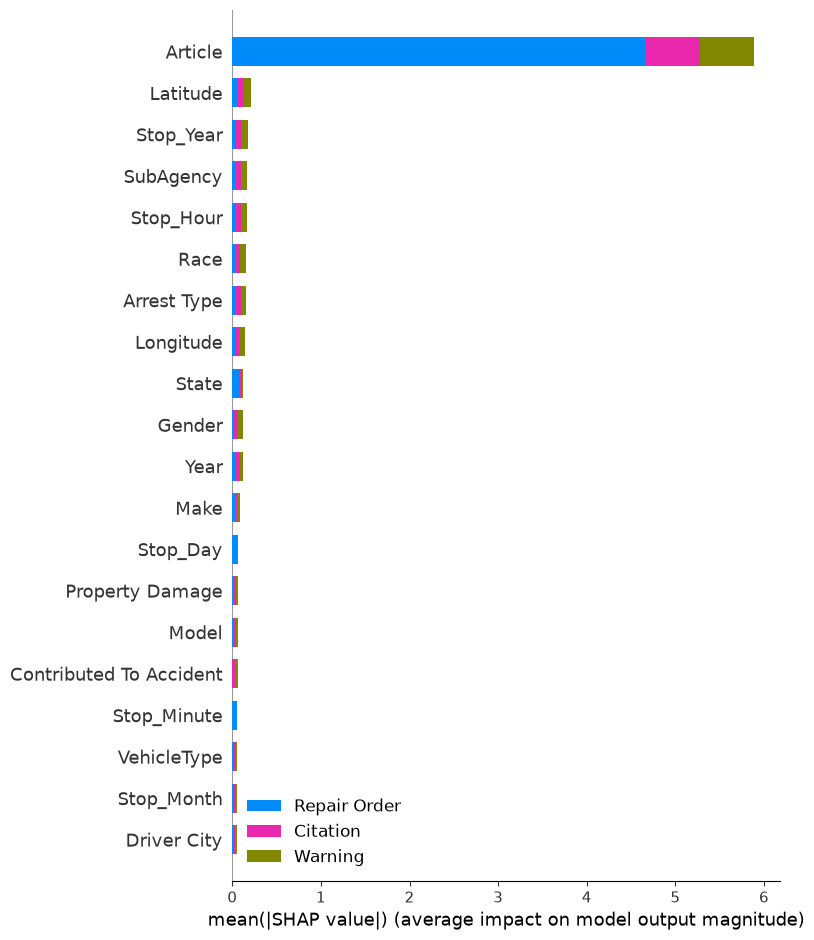

In [ ]:
# SHAP Analysis - Balanced XGBoost


import shap

explainer = shap.TreeExplainer(
    xgb_model_balanced)

sample_size = min(500, len(X_test))

X_shap = X_test[:sample_size]

shap_values = explainer.shap_values(
    X_shap)

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    class_names=[
        "Citation",
        "Repair Order",
        "Warning"],
    show=True)

In [ ]:
# Final Accuracy Comparison Table


accuracy_table = pd.DataFrame({
    "Model": models,

    "Before Balancing (%)":
        np.array(accuracy_before) * 100,

    "After Random Oversampling (%)":
        np.array(accuracy_after) * 100})

accuracy_table.round(2)

,Model,Before Balancing (%),After Random Oversampling (%)
0,Decision Tree,71.54,71.27
1,Random Forest,77.51,77.45
2,XGBoost,70.75,70.70
3,Voting,72.85,72.58
4,Stacking,77.56,77.51


In [ ]:
# Final Model Evaluation Table

rows = []

for model_name in models:

    report = classification_report(
        y_test,
        balanced_predictions[model_name],
        target_names=target_encoder.classes_,
        output_dict=True)

    rows.append({
        "Model": model_name,
        "Accuracy (%)": accuracy_after[models.index(model_name)] * 100,
        "Citation F1": report["Citation"]["f1-score"],
        "Repair Order F1": report["Repair Order"]["f1-score"],
        "Warning F1": report["Warning"]["f1-score"],
        "Macro F1": report["macro avg"]["f1-score"]})

final_evaluation_table = pd.DataFrame(rows)

final_evaluation_table.round(3)

,Model,Accuracy (%),Citation F1,Repair Order F1,Warning F1,Macro F1
0,Decision Tree,71.269,0.706,0.999,0.689,0.798
1,Random Forest,77.451,0.745,0.999,0.778,0.841
2,XGBoost,70.696,0.666,0.999,0.714,0.793
3,Voting,72.578,0.714,0.999,0.709,0.807
4,Stacking,77.512,0.747,0.999,0.777,0.841
